In the results, we see that there are some models with really high estimation errors. The question might rise what causes this. In this notebook, we use an example how these large errors arise from bad predictions in the high-threat states. 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import sys
sys.path.append("../../")
from xThreat import xThreat

# Import the data

In [5]:
# Load both old and new error dataframes
df_errors_old = pd.read_csv('../../3-calculate-values/s4.1-model-error-distribution/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
df_errors_new = pd.read_csv('../../3-calculate-values/s4.1-model-error-distribution/bootstrap_errors_normal_xthreat_extended.csv').rename(columns={'sample_size': 'N'})

# Append the new errors to the old errors
df_errors = pd.concat([df_errors_old, df_errors_new], ignore_index=True)

# Add columns
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']

In [6]:
# Make the norm a dimension independent norm
for col in df_errors.columns.tolist():
    if '1_norm' in col:
        df_errors[col] = df_errors[col]/df_errors['M']
    if ' 2_norm' in col:
        df_errors[col] = df_errors[col]/np.sqrt(df_errors['M'])

# Quick inspection of data

In [7]:
df_errors.head(10)

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,weighted_transition_matrix_error_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000561,0.000314,0.007967,0.000580,0.000403,...,0.010799,0.500000,0.022223,0.131414,1.0,1.0,0.005083,192,0.0005,0.50472
1,16,12,4000000,1,5176043,0.000338,0.000166,0.006788,0.000344,0.000401,...,0.010130,0.500000,0.008385,0.117864,1.0,1.0,0.003691,192,0.0005,0.50472
2,16,12,4000000,2,5176044,0.000370,0.000248,0.009014,0.000351,0.000414,...,0.011958,0.500000,0.006650,0.132075,1.0,1.0,0.006166,192,0.0005,0.50472
3,16,12,4000000,3,5176045,0.000605,0.000350,0.005589,0.000430,0.000438,...,0.015174,0.157143,0.011811,0.133729,1.0,1.0,0.004812,192,0.0005,0.50472
4,16,12,4000000,4,5176046,0.000337,0.000259,0.008731,0.000483,0.000433,...,0.017580,0.500000,0.012102,0.139206,1.0,1.0,0.006745,192,0.0005,0.50472
5,16,12,4000000,5,5176047,0.000377,0.000295,0.006898,0.000456,0.000424,...,0.013729,0.333333,0.027178,0.135318,1.0,1.0,0.005819,192,0.0005,0.50472
6,16,12,4000000,6,5176048,0.000508,0.000248,0.007864,0.000433,0.000423,...,0.014715,0.300000,0.007857,0.137429,1.0,1.0,0.005198,192,0.0005,0.50472
7,16,12,4000000,7,5176049,0.000516,0.000312,0.007096,0.000379,0.000428,...,0.009123,0.500000,0.012317,0.125164,1.0,1.0,0.005345,192,0.0005,0.50472
8,16,12,4000000,8,5176050,0.000260,0.000174,0.009133,0.000469,0.000433,...,0.008392,0.500000,0.010998,0.122867,1.0,1.0,0.003990,192,0.0005,0.50472
9,16,12,4000000,9,5176051,0.000322,0.000225,0.011043,0.000332,0.000404,...,0.012429,0.500000,0.007486,0.126872,1.0,1.0,0.005036,192,0.0005,0.50472


In [8]:
df_errors.describe()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,weighted_transition_matrix_error_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N)
count,104000.000000,104000.000000,1.040000e+05,104000.000000,1.040000e+05,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000,...,104000.000000,104000.000000,104000.000000,104000.000000,104000.0,1.040000e+05,104000.000000,104000.000000,104000.000000,104000.000000
mean,28.615385,21.538462,8.675000e+05,499.500000,2.974503e+06,0.002411,0.001614,0.018743,0.002998,0.001362,...,0.198094,0.775295,0.206899,0.874459,1.0,1.000000e+00,0.097886,847.846154,0.001835,11.341260
std,17.617988,13.141983,1.240810e+06,288.676378,1.791256e+06,0.002003,0.001451,0.007044,0.002652,0.000662,...,0.275085,0.263507,0.293916,0.636935,0.0,2.235204e-16,0.136676,934.112527,0.000873,16.215806
min,8.000000,6.000000,1.000000e+05,0.000000,6.880420e+05,0.000060,0.000025,0.003151,0.000073,0.000294,...,0.000288,0.041188,0.000859,0.019656,1.0,1.000000e+00,0.000422,48.000000,0.000500,0.092909
25%,14.000000,11.000000,1.600000e+05,249.750000,1.489292e+06,0.000960,0.000556,0.014339,0.001107,0.000801,...,0.022199,0.500000,0.028177,0.276863,1.0,1.000000e+00,0.010624,154.000000,0.001164,1.089480
50%,24.000000,18.000000,3.050000e+05,499.500000,2.464542e+06,0.001771,0.001091,0.018662,0.002057,0.001288,...,0.072694,0.943662,0.075693,0.733746,1.0,1.000000e+00,0.043155,432.000000,0.001843,4.202079
75%,40.000000,30.000000,7.975000e+05,749.250000,4.256791e+06,0.003241,0.002210,0.022536,0.004038,0.001876,...,0.232909,1.000000,0.217000,1.489838,1.0,1.000000e+00,0.134260,1200.000000,0.002512,14.028312
max,64.000000,48.000000,4.000000e+06,999.000000,8.705041e+06,0.011238,0.007951,0.067543,0.014307,0.003546,...,1.000000,1.000000,1.000000,1.929577,1.0,1.000000e+00,1.159943,3072.000000,0.003162,78.008388


### Inspection of case with error = 1.0

In [10]:
df_errors[df_errors['xT_error_inf_norm'] == 1.0].head(1)

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,weighted_transition_matrix_error_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N)
41169,64,48,1300000,169,6004211,0.002573,0.001988,0.010295,0.003698,0.000586,...,1.0,1.0,1.0,1.566667,1.0,1.0,0.206922,3072,0.000877,21.635634


In [13]:
xT_true = xThreat.load_from_pickle('../../2-train-models/model-storage/true-models/xt-full-data-n_x64-n_y48.pickle')
xT_resampled = xThreat.load_from_pickle('../../2-train-models/model-storage/resampled-models/xt-N1300000-n_x64-n_y48-i_bootstrap169-random_state6004211.pickle')

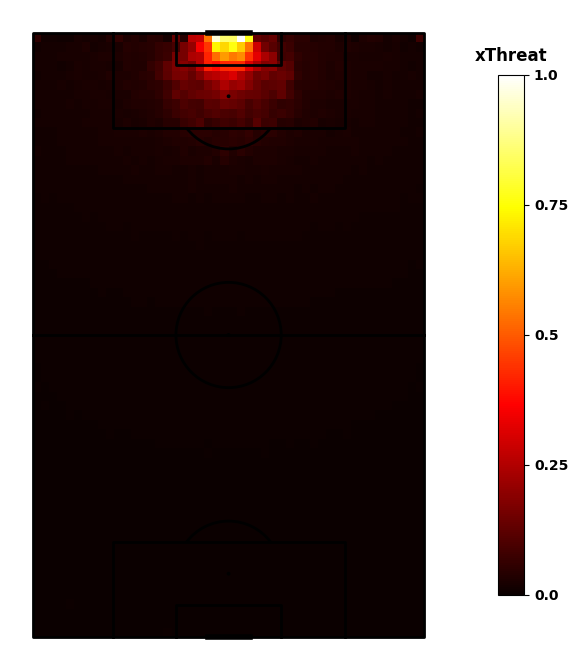

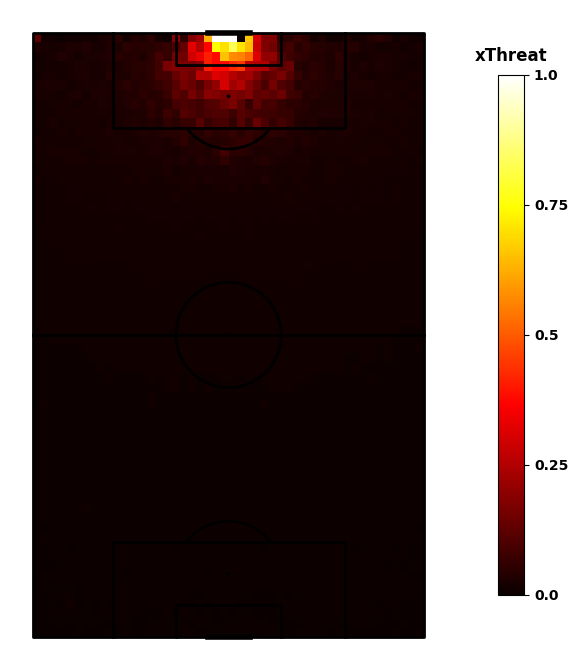

In [14]:
xT_true.plot_xThreat()
xT_resampled.plot_xThreat()

It is clearly visible which state causes the large estimation error. This is caused by the fact that this state did not have enough visits in the data set, meaning the model assigned it a 0-chance probability of scoring directly. As this state is close to the goal, it has a large impect on the final xT-values.